**Data Loading and Cleaning**

In [66]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
from sklearn.manifold import Isomap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, f1_score, log_loss, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC


folder_path = 'PL_matches'
all_szns = []
rand_st = 6740

if not os.path.exists(folder_path):
    print(f"Error: The folder '{folder_path}' was not found in the current directory.")
else:
    # Files specifically inside that folder
    pl_files = sorted([f for f in os.listdir(folder_path) if f.startswith('PL-') and f.endswith('.csv')])
    all_szns = []

# Concatenation of all season datasets
for file in pl_files: # loop through each file
    try:
        df = pd.read_csv(os.path.join(folder_path, file), encoding='unicode_escape')
        cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
    
        if all(col in df.columns for col in cols): # check if all required columns are present
            df = df[cols].copy()
            df = df.dropna(how='all')
            df = df.dropna(subset=['HomeTeam', 'AwayTeam', 'Date'])
            all_szns.append(df)
        else:
            print(f"Error: Missing columns in file {file}")
    
    except Exception as e:
        print(f"Error processing file {file}: {e}")

if all_szns:    
    pl_df = pd.concat(all_szns, ignore_index=True)
    # Parsing dates
    pl_df['Date'] = pd.to_datetime(pl_df['Date'], dayfirst=True)
    pl_df = pl_df.sort_values(by='Date').reset_index(drop=True)
    print(f"Total number of matches: {len(pl_df)}")
else:
    print("No valid data to process.")

pl_df.head()

Total number of matches: 4560


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2013-08-17,Arsenal,Aston Villa,1.0,3.0,A,16.0,9.0,4.0,4.0,15.0,18.0,4.0,3.0,4.0,5.0,1.0,0.0
1,2013-08-17,Liverpool,Stoke,1.0,0.0,H,26.0,10.0,11.0,4.0,11.0,11.0,12.0,6.0,1.0,1.0,0.0,0.0
2,2013-08-17,Norwich,Everton,2.0,2.0,D,8.0,19.0,2.0,6.0,13.0,10.0,6.0,8.0,2.0,0.0,0.0,0.0
3,2013-08-17,Sunderland,Fulham,0.0,1.0,A,20.0,5.0,3.0,1.0,14.0,14.0,6.0,1.0,0.0,3.0,0.0,0.0
4,2013-08-17,Swansea,Man United,1.0,4.0,A,17.0,15.0,6.0,7.0,13.0,10.0,7.0,4.0,1.0,3.0,0.0,0.0


**Feature Engineering: ELO, Clinicalness in front of goal, Form, Rest Days**

In [67]:
# Elo Rating System Implementation
team_elos = {}
init_elo = 1500 # starting Elo rating for new teams
all_clubs = set(pl_df['HomeTeam'].unique()).union(set(pl_df['AwayTeam'].unique()))
for club in all_clubs:
    team_elos[club] = init_elo
k_factor = 20 # sensitivity factor for Elo updates
elo_home = []
elo_away = []
print("Loading Elo Ratings...")

for index, row in pl_df.iterrows():
    h_team = row['HomeTeam']
    a_team = row['AwayTeam']
    h_elo = team_elos.get(h_team, init_elo) # get home team Elo, default to init_elo otherwise
    a_elo = team_elos.get(a_team, init_elo) # get away team Elo, default to init_elo otherwise
    # Storing current Elo ratings
    elo_home.append(h_elo)
    elo_away.append(a_elo)
    # Expected result calculation: 1 / (1 + 10^((opponent_elo - team_elo)/400))
    dr = h_elo - a_elo + 100 # +100 adds home advantage
    e_home = 1 / (1 + 10**(-dr / 400)) # expected score for home team

    # Actual result
    if row['FTR'] == 'H':
        s_home = 1.0
    elif row['FTR'] == 'D':
        s_home = 0.5
    else:
        s_home = 0.0
    
    # Elo rating updates
    team_elos[h_team] = h_elo + k_factor * (s_home - e_home)
    team_elos[a_team] = a_elo + k_factor * ((1 - s_home) - (1 - e_home))

# Adding Elo ratings to dataframe
pl_df['HomeElo'] = elo_home
pl_df['AwayElo'] = elo_away
print("Elo Ratings Loaded.")

# Prepping the data for rolling averages (form over last 5 matches)
def get_team_stats(matches):
    # Home team stats
    home_df = matches[['Date', 'HomeTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'HST']].copy()
    home_df.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst', 'Result', 'Shots', 'ShotsTarget']
    home_df['IsHome'] = 1
    home_df['Points'] = home_df['Result'].map({'H': 3, 'D': 1, 'A': 0})
    # Away team stats
    away_df = matches[['Date', 'AwayTeam', 'FTAG', 'FTHG', 'FTR', 'AS', 'AST']].copy()
    away_df.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst', 'Result', 'Shots', 'ShotsTarget']
    away_df['IsHome'] = 0
    away_df['Points'] = away_df['Result'].map({'A': 3, 'D': 1, 'H': 0})
    # Combine home and away stats and sort
    return pd.concat([home_df, away_df], ignore_index=True).sort_values(by='Date')
team_stats = get_team_stats(pl_df)

print("Loading Rolling Averages (Form over last 5 matches)...")

metrics = ['GoalsFor', 'GoalsAgainst', 'Points', 'Shots', 'ShotsTarget']

rolling_stats = team_stats.groupby('Team')[metrics].apply(lambda x: x.shift(1).rolling(window=5, min_periods=3).mean()) # .shift(1) to avoid data leakage
rolling_stats.columns = [f'Roll5_{col}' for col in rolling_stats.columns]

if isinstance(rolling_stats.index, pd.MultiIndex):
    rolling_stats = rolling_stats.reset_index(level=0, drop=True)
    
team_stats = pd.concat([team_stats, rolling_stats], axis=1) # merge rolling stats back to team_stats

# Clinicalness (Shots on Target / Shots)
team_stats['Roll5_ShotAcc'] = team_stats['Roll5_ShotsTarget'] / team_stats['Roll5_Shots']
team_stats['Roll5_ShotAcc'] = team_stats['Roll5_ShotAcc'].fillna(0) # for cases with 0 shots

# Fatigue (Days since last match)
team_stats['PrevMatchDate'] = team_stats.groupby('Team')['Date'].shift(1)
team_stats['RestDays'] = (team_stats['Date'] - team_stats['PrevMatchDate']).dt.days
team_stats['RestDays'] = team_stats['RestDays'].fillna(7) # assume 7 days rest if no previous match
print("Rolling Averages Loaded.")

# Merge back to main dataframe
print("Merging and Finalizing...")

team_stats = team_stats.dropna(subset=['Roll5_Points']) # drop rows where rolling stats are NaN
cols_to_merge = ['Date', 'Team', 'RestDays', 'Roll5_Points', 'Roll5_GoalsFor', 'Roll5_GoalsAgainst', 'Roll5_ShotAcc']
home_stats = team_stats[team_stats['IsHome'] == 1][cols_to_merge]
home_stats.columns = ['Date', 'HomeTeam', 'HomeRestDays', 'HomeForm', 'HomeAttack', 'HomeDefense', 'HomeShotAcc']
away_stats = team_stats[team_stats['IsHome'] == 0][cols_to_merge]
away_stats.columns = ['Date', 'AwayTeam', 'AwayRestDays', 'AwayForm', 'AwayAttack', 'AwayDefense', 'AwayShotAcc']

# Merging home and away stats
final_df = pd.merge(pl_df, home_stats, on=['Date', 'HomeTeam'], how='inner')
final_df = pd.merge(final_df, away_stats, on=['Date', 'AwayTeam'], how='inner')
final_df['Target'] = final_df['FTR'].map({'H': 0, 'D': 1, 'A': 2}) # Target variable; 0=Home Win, 1=Draw, 2=Away Win
final_cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'Target', 'HomeElo', 'AwayElo', 'HomeForm', 'AwayForm', 
              'HomeRestDays', 'AwayRestDays', 'HomeShotAcc', 'AwayShotAcc', 'HomeAttack', 'AwayAttack', 
              'HomeDefense', 'AwayDefense']
final_df = final_df[final_cols]
print("Merging and Finalizing Completed.")
print(f"Shape of final dataset: {final_df.shape}")
print(final_df.head())

Loading Elo Ratings...
Elo Ratings Loaded.
Loading Rolling Averages (Form over last 5 matches)...
Rolling Averages Loaded.
Merging and Finalizing...
Merging and Finalizing Completed.
Shape of final dataset: (4485, 17)
        Date    HomeTeam        AwayTeam FTR  Target      HomeElo  \
0 2013-09-14       Stoke        Man City   D       1  1512.910209   
1 2013-09-14   Tottenham         Norwich   H       0  1511.634816   
2 2013-09-14  Man United  Crystal Palace   H       0  1503.108283   
3 2013-09-14  Sunderland         Arsenal   A       2  1483.184235   
4 2013-09-14      Fulham       West Brom   D       1  1491.898085   

       AwayElo  HomeForm  AwayForm  HomeRestDays  AwayRestDays  HomeShotAcc  \
0  1506.825918  2.000000  2.000000          14.0          14.0     0.358974   
1  1497.605284  2.000000  1.333333          13.0          14.0     0.220000   
2  1487.627849  1.333333  1.000000          13.0          14.0     0.368421   
3  1508.365184  0.333333  2.000000          14.0   

Data Scaled. Mean of first feature: 0.00, Std: 1.00


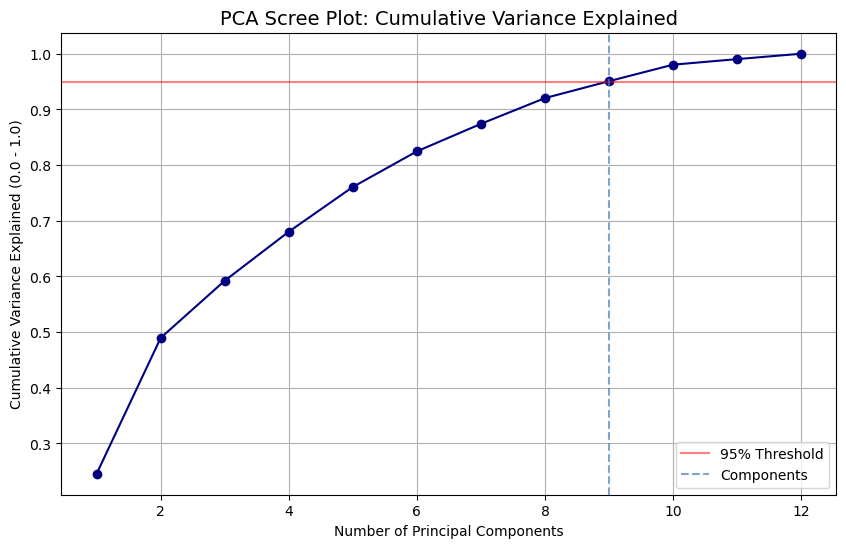

Number of components needed to explain 95% variance: 9


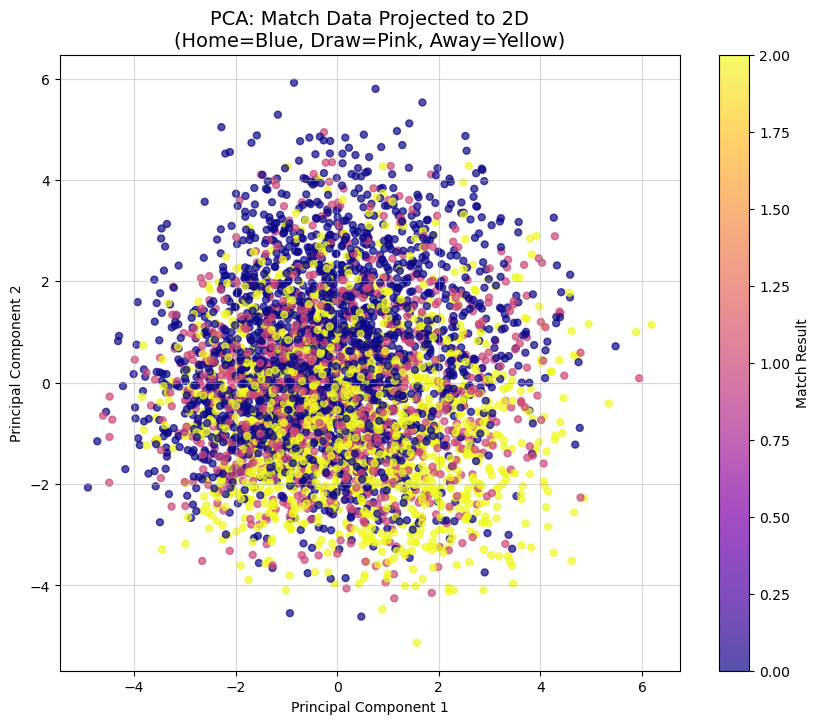

In [68]:
# Prepping the feature columns (excluding Date, Teams, Target)
feature_cols = ['HomeElo', 'AwayElo', 'HomeForm', 'AwayForm', 
                'HomeRestDays', 'AwayRestDays',
                'HomeShotAcc', 'AwayShotAcc', 
                'HomeAttack', 'AwayAttack', 
                'HomeDefense', 'AwayDefense']

X = final_df[feature_cols]
y = final_df['Target']  # 0=Home, 1=Draw, 2=Away

if X.isnull().values.any(): # check for NaNs
    print("Warning: NaNs found. Filling with mean...")
    X = X.fillna(X.mean())

# Scaling for PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data Scaled. Mean of first feature: {:.2f}, Std: {:.2f}".format(
    X_scaled[:, 0].mean(), X_scaled[:, 0].std()))


# PCA Scree Plot
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate Cumulative Variance Explained
cm_var = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cm_var) + 1), cm_var, marker='o', linestyle='-', color='navy')
plt.title('PCA Scree Plot: Cumulative Variance Explained', fontsize=14)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained (0.0 - 1.0)')
plt.axhline(y=0.95, color='red', linestyle='-', label='95% Threshold', alpha=0.5)
plt.axvline(x=n_components_95, color='steelblue', linestyle='--', label=f'Components', alpha=0.7)
plt.grid(True)
plt.legend()
plt.show()

# Find exact number of components for 95% variance
n_components_95 = np.argmax(cm_var >= 0.95) + 1 # +1 for index to count
print(f"Number of components needed to explain 95% variance: {n_components_95}")

# Visualizing 2D Projection
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', alpha=0.7, s=25)
plt.title(f'PCA: Match Data Projected to 2D\n(Home=Blue, Draw=Pink, Away=Yellow)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Match Result')
plt.grid(True, alpha=0.5)
plt.show()

**ISOMAP Visualization**

Visualizing ISOMAP on 2000 samples...


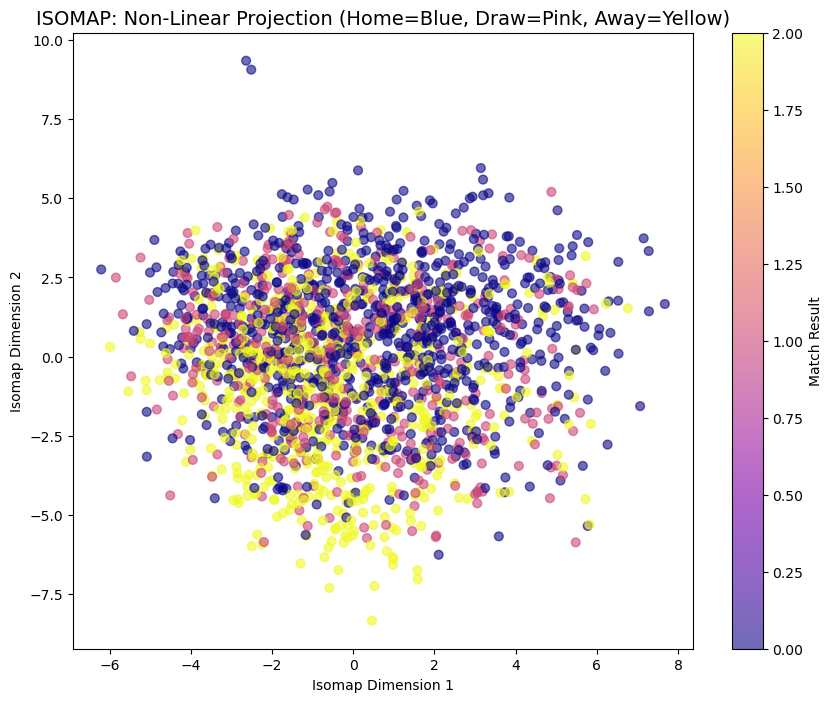

In [69]:
print("Visualizing ISOMAP on 2000 samples...")
sample_idx = np.random.choice(X_scaled.shape[0], 2000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y.iloc[sample_idx]

iso = Isomap(n_neighbors=20, n_components=2) # using 20 neighbors
X_iso = iso.fit_transform(X_sample)

plt.figure(figsize=(10, 8))
scatter_iso = plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y_sample, cmap='plasma', alpha=0.6, s=40)
plt.title('ISOMAP: Non-Linear Projection (Home=Blue, Draw=Pink, Away=Yellow)', fontsize=14)
plt.xlabel('Isomap Dimension 1')
plt.ylabel('Isomap Dimension 2')
plt.colorbar(scatter_iso, label='Match Result')
plt.show()

**Model Setup**

In [70]:
results = []
tscv = TimeSeriesSplit(n_splits=5) # 5-fold time series split

models = {
    'Baseline Dummy': DummyClassifier(strategy='most_frequent'), # baseline model
    'Lasso Regression': LogisticRegression(penalty='l1', max_iter=1000, C=0.1, solver='liblinear', # regularized logistic regression
                                           multi_class='ovr', random_state=rand_st), 
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=rand_st, max_depth=5), # decision tree based model
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss', random_state=rand_st), # gradient boosting model
    'SVM': SVC(kernel='rbf', C=1.0, probability=True, random_state=rand_st) # Support Vector Machine
}

print(f"Initiating Time Series Cross-Validation with {len(X)} splits...")
print("-" * 60)
for model_name, model_inst in models.items():
    # storing raw features, ensures scaling occurs inside CV loop
    # prevents data leakage
    pipe_raw = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model_inst)
    ])
    metrics_raw = {'acc': [], 'f1': [], 'logloss': []}
    
    # storing PCA features
    pipe_pca = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_components_95)),
        ('classifier', model_inst)
    ])
    metrics_pca = {'acc': [], 'f1': [], 'logloss': []}
    
    # Time Series Cross-Validation loop
    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # training and evaluating raw features
        pipe_raw.fit(X_train, y_train)
        y_pred_raw = pipe_raw.predict(X_test)
        y_proba_raw = pipe_raw.predict_proba(X_test)
        
        metrics_raw['acc'].append(accuracy_score(y_test, y_pred_raw))
        metrics_raw['f1'].append(f1_score(y_test, y_pred_raw, average='macro')) # macro f1 to handle "Draw" class bias
        metrics_raw['logloss'].append(log_loss(y_test, y_proba_raw))
        
        # training and evaluating PCA features
        pipe_pca.fit(X_train, y_train)
        y_pred_pca = pipe_pca.predict(X_test)
        y_proba_pca = pipe_pca.predict_proba(X_test)
        
        metrics_pca['acc'].append(accuracy_score(y_test, y_pred_pca))
        metrics_pca['f1'].append(f1_score(y_test, y_pred_pca, average='macro')) # macro f1 to handle "Draw" class bias
        metrics_pca['logloss'].append(log_loss(y_test, y_proba_pca))
        
    # Averaging metrics across folds
    results.append({
        'Model': model_name,
        'Feature Set': 'Raw (12 features)',
        'Accuracy': np.mean(metrics_raw['acc']),
        'Macro F1': np.mean(metrics_raw['f1']),
        'Log Loss': np.mean(metrics_raw['logloss'])
    })
    results.append({
        'Model': model_name,
        'Feature Set': f'PCA ({n_components_95} features)',
        'Accuracy': np.mean(metrics_pca['acc']),
        'Macro F1': np.mean(metrics_pca['f1']),
        'Log Loss': np.mean(metrics_pca['logloss'])
    })
    print(f"Completed model: {model_name}")
    print("-" * 60) # end of model loop

# Displaying results
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("Cross-Validation Results:\n")
print(results_df)

Initiating Time Series Cross-Validation with 4485 splits...
------------------------------------------------------------
Completed model: Baseline Dummy
------------------------------------------------------------
Completed model: Lasso Regression
------------------------------------------------------------
Completed model: Random Forest
------------------------------------------------------------
Completed model: XGBoost
------------------------------------------------------------
Completed model: SVM
------------------------------------------------------------
Cross-Validation Results:

              Model        Feature Set  Accuracy  Macro F1   Log Loss
2  Lasso Regression  Raw (12 features)  0.540562  0.398531   0.978211
3  Lasso Regression   PCA (9 features)  0.538153  0.396070   0.984208
4     Random Forest  Raw (12 features)  0.534940  0.395116   0.991673
8               SVM  Raw (12 features)  0.533869  0.395739   1.002156
9               SVM   PCA (9 features)  0.530924  0.39

**Analyzing the models**

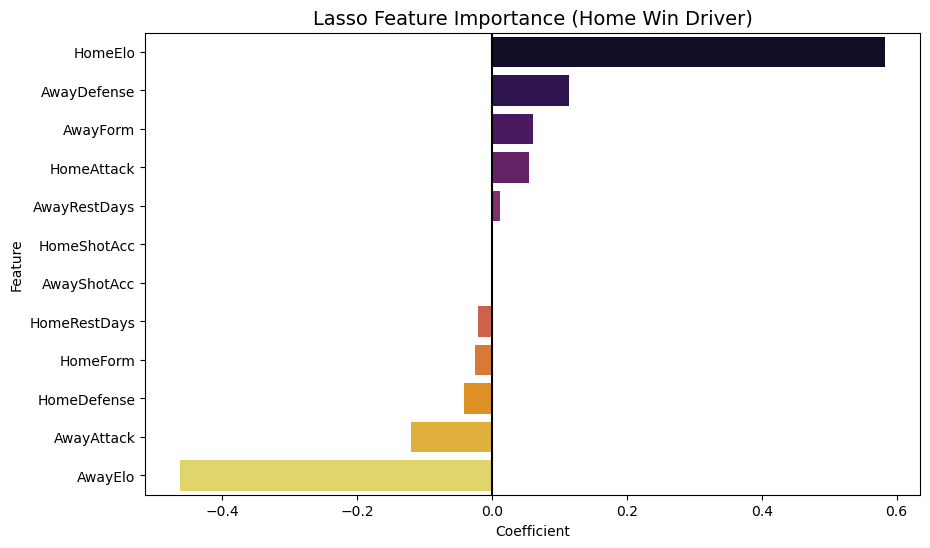

         Feature  Coefficient
0        HomeElo     0.582568
11   AwayDefense     0.114991
3       AwayForm     0.061195
8     HomeAttack     0.054552
5   AwayRestDays     0.012276
6    HomeShotAcc     0.000000
7    AwayShotAcc     0.000000
4   HomeRestDays    -0.020052
2       HomeForm    -0.024569
10   HomeDefense    -0.041014
9     AwayAttack    -0.120497
1        AwayElo    -0.461818


In [71]:
final_model = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', multi_class='ovr', random_state=rand_st)
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X)
final_model.fit(X_final_scaled, y)

# Storing the coefficients
coeffs = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': final_model.coef_[0]  # Coefficients for class 'Home Win' (0)
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coeffs, palette='inferno')
plt.title('Lasso Feature Importance (Home Win Driver)', fontsize=14)
plt.axvline(x=0, color='k', linestyle='-')
plt.show()
print(coeffs)

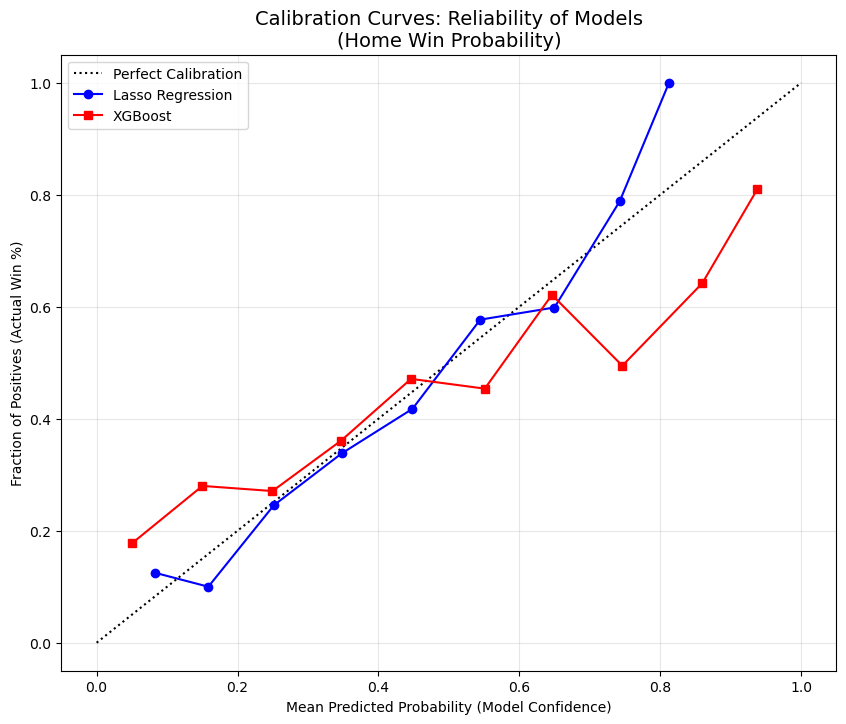

In [72]:
# Lasso vs XGBoost Probability Calibration
split_idx = int(len(X) * 0.8) # 80-20 train-test split
X_train_cal, X_test_cal = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_cal, y_test_cal = y.iloc[:split_idx], y.iloc[split_idx:]

# Pipelines
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', multi_class='ovr', random_state=rand_st))])
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(eval_metric='mlogloss', random_state=rand_st))])
lasso_pipe.fit(X_train_cal, y_train_cal)
xgb_pipe.fit(X_train_cal, y_train_cal)

# Predicting probabilities
prob_lasso = lasso_pipe.predict_proba(X_test_cal)[:, 0]
prob_xgb = xgb_pipe.predict_proba(X_test_cal)[:, 0]

# Calibration data and curve calculations
y_test_binary = (y_test_cal == 0).astype(int) # Binary for 'Home Win'
frac_pos_lasso, mean_pred_lasso = calibration_curve(y_test_binary, prob_lasso, n_bins=10) # fraction of positives vs mean predicted
frac_pos_xgb, mean_pred_xgb = calibration_curve(y_test_binary, prob_xgb, n_bins=10)

# Plotting calibration curves
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label='Perfect Calibration')
plt.plot(mean_pred_lasso, frac_pos_lasso, "o-", label='Lasso Regression', color='blue')
plt.plot(mean_pred_xgb, frac_pos_xgb, "s-", label='XGBoost', color='red')
plt.ylabel('Fraction of Positives (Actual Win %)')
plt.xlabel('Mean Predicted Probability (Model Confidence)')
plt.title('Calibration Curves: Reliability of Models\n(Home Win Probability)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Load Odds Data**

In [73]:
print("Extracting Betting Odds Data...")
odds_list = []
for file in pl_files: # loop through each file
    try:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, encoding='unicode_escape')
        odds_cols = ['Date', 'HomeTeam', 'AwayTeam', 'B365H', 'B365D', 'B365A'] # Bet365 odds
        if all(c in df.columns for c in odds_cols):
            oddset = df[odds_cols].copy()
            oddset = oddset.dropna()
            odds_list.append(oddset)
        else:
            print(f"Error")
    except Exception as e:
        print(f"Error processing file {file}: {e}")

odds_df = pd.concat(odds_list, ignore_index=True)
odds_df['Date'] = pd.to_datetime(odds_df['Date'], dayfirst=True)
print(f"Betting Odds Data Loaded for {len(odds_df)} matches.")
print(odds_df.head())

Extracting Betting Odds Data...
Betting Odds Data Loaded for 4560 matches.
        Date    HomeTeam     AwayTeam  B365H  B365D  B365A
0 2013-08-17     Arsenal  Aston Villa   1.44   4.75    8.0
1 2013-08-17   Liverpool        Stoke   1.40   5.00    9.5
2 2013-08-17     Norwich      Everton   3.20   3.40    2.4
3 2013-08-17  Sunderland       Fulham   2.30   3.40    3.4
4 2013-08-17     Swansea   Man United   4.20   3.50    2.0


In [74]:
df_with_odds = pd.merge(final_df, odds_df, on=['Date', 'HomeTeam'], how='inner')
feature_cols = ['HomeElo', 'AwayElo', 'HomeForm', 'AwayForm', 
                'HomeRestDays', 'AwayRestDays',
                'HomeShotAcc', 'AwayShotAcc', 
                'HomeAttack', 'AwayAttack', 
                'HomeDefense', 'AwayDefense']
X_odds = df_with_odds[feature_cols]
y_odds = df_with_odds['Target']
odds_data = df_with_odds[['B365H', 'B365D', 'B365A']]
print(f"Merged dataset shape with odds: {df_with_odds.shape}")

Merged dataset shape with odds: (4485, 21)


**Formatting Odds -> Probabilities**

In [ ]:
# Calculating implied probabilities from betting odds
bookie_probs = 1 / odds_data[['B365H', 'B365D', 'B365A']].values
normalized_probs = bookie_probs / bookie_probs.sum(axis=1, keepdims=True)
# Bookie predictions
bookie_preds = np.argmax(normalized_probs, axis=1)

# Calculating scores
bookie_accuracy = accuracy_score(y_odds, bookie_preds)
bookie_logloss = log_loss(y_odds, normalized_probs)
print(f"Market Benchmark - Accuracy: {bookie_accuracy:.4f}, Log Loss: {bookie_logloss:.4f}")

Market Benchmark - Accuracy: 0.5579, Log Loss: 0.9537


**McNemar's Test**

In [77]:
from statsmodels.stats.contingency_tables import mcnemar

train_idx, test_idx = list(tscv.split(X))[-1] # last split
X_train_last, X_test_last = X.iloc[train_idx], X.iloc[test_idx]
y_train_last, y_test_last = y.iloc[train_idx], y.iloc[test_idx]

# Best model: Lasso on raw features
final_raw_lasso = Pipeline([('scaler', StandardScaler()),
                         ('clf', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', multi_class='ovr', random_state=rand_st))])
final_raw_lasso.fit(X_train_last, y_train_last)

# Second best model: Lasso on PCA features
final_pca_lasso = Pipeline([('scaler', StandardScaler()), ('pca', PCA(n_components=n_components_95)),
                        ('clf', LogisticRegression(penalty='l1', C=0.1, solver='liblinear', multi_class='ovr', random_state=rand_st))])
final_pca_lasso.fit(X_train_last, y_train_last)

# Third best model: Random Forest on raw features
final_raw_rf = Pipeline([('scaler', StandardScaler()),
                      ('clf', RandomForestClassifier(n_estimators=100, random_state=rand_st, max_depth=5))])
final_raw_rf.fit(X_train_last, y_train_last)

# Baseline: Dummy Classifier
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_last, y_train_last)

# Predictions
pred_lasso_raw = final_raw_lasso.predict(X_test_last)
pred_lasso_pca = final_pca_lasso.predict(X_test_last)
pred_rf_raw = final_raw_rf.predict(X_test_last)
pred_dummy = dummy_clf.predict(X_test_last)

def run_mcnemar(y_true, pred_a, pred_b, name_a, name_b):
    # Boolean calculations for correct/incorrect
    a_correct = (pred_a == y_true)
    b_correct = (pred_b == y_true)

    # Contingency table
    # n11: both correct
    # n10: A correct, B incorrect
    # n01: A incorrect, B correct
    # n00: both incorrect
    n11 = np.sum(a_correct & b_correct)
    n10 = np.sum(a_correct & ~b_correct)
    n01 = np.sum(~a_correct & b_correct)
    n00 = np.sum(~a_correct & ~b_correct)
    contingency_table = [[n11, n10],
                         [n01, n00]]
    result = mcnemar(contingency_table, exact=False, correction=True) # using continuity correction
    print(f"McNemar's Test between {name_a} and {name_b}:")
    print(f"Contingency Table: {contingency_table}")
    print(f"Chi-Squared: {result.statistic:.4f}, p-value: {result.pvalue:.4f}")

    if result.pvalue < 0.05:
        print("Result: Significant difference in performance (reject H0)")
        print(f"{name_a} and {name_b} have statistically different accuracies.\n")
    else:
        print("Result: No significant difference in performance (fail to reject H0)")
        print(f"{name_a} and {name_b} do not have statistically different accuracies.\n")

# Running Comparisons
run_mcnemar(y_test_last, pred_lasso_raw, pred_dummy, "Lasso Raw", "Baseline") # Did the model learn?
run_mcnemar(y_test_last, pred_lasso_raw, pred_lasso_pca, "Lasso Raw", "Lasso PCA") # Effect of PCA
run_mcnemar(y_test_last, pred_lasso_raw, pred_rf_raw, "Lasso Raw", "Random Forest Raw") # Lasso vs RF


McNemar's Test between Lasso Raw and Baseline:
Contingency Table: [[np.int64(271), np.int64(146)], [np.int64(54), np.int64(276)]]
Chi-Squared: 41.4050, p-value: 0.0000
Result: Significant difference in performance (reject H0)
Lasso Raw and Baseline have statistically different accuracies.

McNemar's Test between Lasso Raw and Lasso PCA:
Contingency Table: [[np.int64(384), np.int64(33)], [np.int64(18), np.int64(312)]]
Chi-Squared: 3.8431, p-value: 0.0499
Result: Significant difference in performance (reject H0)
Lasso Raw and Lasso PCA have statistically different accuracies.

McNemar's Test between Lasso Raw and Random Forest Raw:
Contingency Table: [[np.int64(387), np.int64(30)], [np.int64(17), np.int64(313)]]
Chi-Squared: 3.0638, p-value: 0.0801
Result: No significant difference in performance (fail to reject H0)
Lasso Raw and Random Forest Raw do not have statistically different accuracies.

